In [20]:
import pandas as pd

df = pd.read_csv("Youtube-Spam-Dataset.csv")
print(df.head())

                                    COMMENT_ID            AUTHOR  \
0  LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU         Julius NM   
1  LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A       adam riyati   
2  LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8  Evgeny Murashkin   
3          z13jhp0bxqncu512g22wvzkasxmvvzjaz04   ElNino Melendez   
4          z13fwbwp1oujthgqj04chlngpvzmtt3r3dw            GsMega   

                  DATE                                            CONTENT  \
0  2013-11-07T06:20:48  Huh, anyway check out this you[tube] channel: ...   
1  2013-11-07T12:37:15  Hey guys check out my new channel and our firs...   
2  2013-11-08T17:34:21             just for test I have to say murdev.com   
3  2013-11-09T08:28:43   me shaking my sexy ass on my channel enjoy ^_^ ﻿   
4  2013-11-10T16:05:38            watch?v=vtaRGgvGtWQ   Check this out .﻿   

                       VIDEO_NAME  CLASS  
0  PSY - GANGNAM STYLE(?????) M/V      1  
1  PSY - GANGNAM STYLE(?????) M/V      1  

In [21]:
df.columns

Index(['COMMENT_ID', 'AUTHOR', 'DATE', 'CONTENT', 'VIDEO_NAME', 'CLASS'], dtype='str')

In [22]:
df.info()
df['CLASS'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   COMMENT_ID  1956 non-null   str  
 1   AUTHOR      1956 non-null   str  
 2   DATE        1711 non-null   str  
 3   CONTENT     1956 non-null   str  
 4   VIDEO_NAME  1956 non-null   str  
 5   CLASS       1956 non-null   int64
dtypes: int64(1), str(5)
memory usage: 91.8 KB


CLASS
1    1005
0     951
Name: count, dtype: int64

In [23]:
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['clean_text'] = df['CONTENT'].apply(clean_text)

df[['CONTENT', 'clean_text']].head()

,CONTENT,clean_text
0,"Huh, anyway check out this you[tube] channel: ...",huh anyway check out this youtube channel koby...
1,Hey guys check out my new channel and our firs...,hey guys check out my new channel and our firs...
2,just for test I have to say murdev.com,just for test i have to say murdevcom
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,me shaking my sexy ass on my channel enjoy ﻿
4,watch?v=vtaRGgvGtWQ Check this out .﻿,watchvvtarggvgtwq check this out ﻿


In [24]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_tfidf, y_train)

print("Model trained successfully")

Model trained successfully


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.8852040816326531
Precision: 0.9193548387096774
Recall: 0.8507462686567164
F1: 0.8837209302325582


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[176  15]
 [ 30 171]]


Matplotlib is building the font cache; this may take a moment.


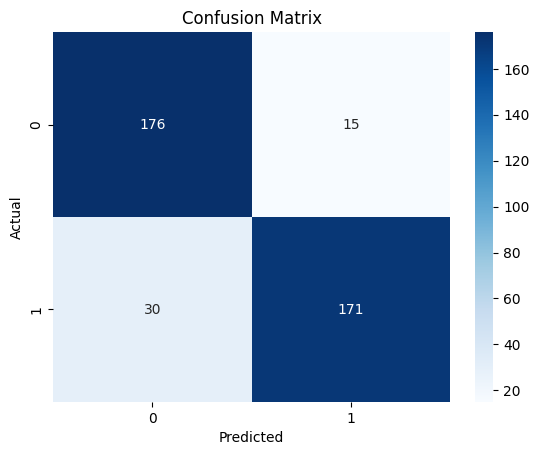

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()